<a href="https://colab.research.google.com/github/25CristopherJoshuaReyesGtz1405/MachineLearning/blob/main/Machine_Learning_Y_Deep_Learning_Pr%C3%A1ctica_No_3_Unidad_III_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![TecNM](https://drive.google.com/uc?id=1HP9R3V9XnozjtY08gGdKhoCKo76MKgLr)

---
<div align="center">

  ## **Machine Learning y Deep Learning**

  ### **Unidad 3 - Aprendizaje Supervisado Con Métodos De Clasificación**

  #### **Práctica No. 3 - El Algoritmo K-NN Dentro De Un Riesgo Crediticio**

</div>

##### **Docente Facilitador** - **Dr. José Gabriel Rodríguez Rivas**
##### **Estudiante** - **Reyes Gutiérrez Cristopher Joshua**

#### **24 de Abril del 2026, Victoria de Durango, Dgo., México**
---

### **1. Introducción**

En la disciplina de la ciencia de datos, la capacidad de abstraer y trasladar conceptos puramente espaciales o geométricos hacia la resolución de problemas financieros representa uno de los enfoques más elegantes y analíticos del aprendizaje automático. Durante el desarrollo de investigaciones previas (específicamente en la Práctica No. 1), se demostró la viabilidad del algoritmo *K-Nearest Neighbors* (K-NN) para clasificar atributos físicos tangibles —tales como la masa y la altura de diversas especies frutales— mediante el cálculo de métricas de distancia. En esta ocasión, la presente investigación técnica aborda un desafío de mayor envergadura comercial: la extrapolación de estas mismas mediciones geométricas hacia la evaluación del riesgo crediticio, tomando como base el ecosistema de datos de la plataforma *Lending Club*.

Al transitar hacia este nuevo contexto, un "punto" dentro del plano cartesiano multidimensional abandona su representación física para convertirse en el expediente financiero completo de un prestatario. Las coordenadas espaciales de este punto ya no están definidas por centímetros o gramos, sino por variables heterogéneas de alto impacto económico, tales como los ingresos anuales del solicitante, la tasa de interés asignada y el monto total del crédito financiado. Bajo este paradigma, la premisa fundamental del algoritmo sugiere que aquellos clientes que exhiben perfiles socioeconómicos y comportamientos de pago similares tenderán a agruparse en vecindarios matemáticamente cercanos dentro del espacio de características. En consecuencia, al evaluar una nueva solicitud de crédito, el modelo buscará a los "vecinos" históricos más próximos para predecir si el nuevo cliente liquidará su deuda o incurrirá en morosidad.

Sin embargo, proyectar variables financieras en un plano geométrico conlleva vulnerabilidades estadísticas severas que deben ser tratadas con rigor metodológico. En primer lugar, la disparidad intrínseca de las magnitudes económicas exige, de manera ineludible, la normalización de los datos; de lo contrario, una variable con valores en decenas de miles (como el ingreso anual) eclipsaría por completo a variables porcentuales (como la tasa de interés). En segundo lugar, y de forma aún más crítica, se debe confrontar el impacto del desequilibrio de clases. En escenarios reales de *Lending Club*, la inmensa mayoría de los puntos en el espacio pertenecen a la clase mayoritaria de "Créditos Pagados". Por consiguiente, a lo largo de este reporte técnico, el lector analizará empíricamente cómo esta aglomeración desproporcionada de datos domina el sistema de "votación" del algoritmo, y por qué la correcta calibración del número de vecinos ($k$) y la estandarización espacial son imperativos absolutos para mitigar el riesgo financiero.

### **2. Objetivos de la Investigación**

#### **2.1 Objetivo General**
Implementar y evaluar el rendimiento predictivo del algoritmo espacial *K-Nearest Neighbors* (K-NN) sobre el conjunto de datos financieros de *Lending Club*, cuantificando de manera empírica su vulnerabilidad ante el desequilibrio de clases y demostrando el impacto analítico de la normalización de características en la detección de morosidad crediticia.

#### **2.2 Objetivos Específicos**
* **Estructurar** la arquitectura del modelo de clasificación basada en instancias, integrando de forma selectiva las variables financieras disponibles antes de la originación del crédito para evitar sesgos predictivos.
* **Evaluar** el rendimiento del algoritmo sobre la matriz de datos en estado crudo (sin normalizar), documentando el déficit de la métrica de Sensibilidad (*Recall*) para la clase de riesgo (No Pagado).
* **Contrastar** el comportamiento de las fronteras de decisión mediante la iteración sistemática del hiperparámetro $k$ (probando con 1, 3, 5 y 10 vecinos), para identificar el grado de suavización geométrica del modelo.
* **Aplicar** el preprocesamiento de estandarización ($Z$-score) utilizando la clase `StandardScaler`, logrando proyectar equitativamente variables financieras de magnitudes dispares y optimizando así la precisión del cálculo de distancias.

### **3. Antecedentes De Investigación**

#### **3.1 Naturaleza del Aprendizaje Basado en Memoria (*Lazy Learning*)**
A diferencia de los modelos paramétricos tradicionales que deducen una ecuación matemática global durante el entrenamiento (como la Regresión Logística), el algoritmo K-NN se clasifica dentro de la categoría de aprendizaje "perezoso" o basado en instancias (*Instance-based learning*). Esta denominación técnica radica en el hecho de que el modelo no genera una función de frontera explícita; por el contrario, su fase de "entrenamiento" se limita estrictamente a memorizar la totalidad del conjunto de datos históricos. La inferencia solo ocurre en el tiempo de predicción, momento en el cual el algoritmo mide las distancias desde la nueva instancia hacia todos los puntos memorizados, selecciona los $k$ más cercanos, y asigna la etiqueta final basándose en una agregación por mayoría simple de votos.

#### **3.2 Fundamentos de la Distancia Espacial en Finanzas**
Para que este proceso de agrupación iterativa sea exitoso, el modelo requiere imperativamente de una métrica que cuantifique la similitud. Por defecto, K-NN emplea la **Distancia Euclidiana**, la cual se define como la longitud del segmento de recta que conecta dos puntos en el espacio multidimensional:

$$d(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$

En el contexto de *Lending Club*, cada variable predictora (monto, tasa, ingresos, etc.) representa una dimensión ($n$) en la sumatoria de esta ecuación. Si dos clientes poseen finanzas casi idénticas, su distancia euclidiana tenderá a cero.

#### **3.3 La Sensibilidad a la Escala y el Efecto del Desequilibrio**
La robustez de esta ecuación matemática es, paradójicamente, su mayor debilidad analítica cuando se trata de finanzas. Si no se interviene la escala original de los datos, el cálculo de la distancia quedará secuestrado por las características de mayor denominación numérica, anulando la aportación de indicadores cruciales pero de escala menor (como el nivel de endeudamiento o *DTI*).

Aunado a lo anterior, la votación por mayoría simple se vuelve defectuosa frente a conjuntos de datos con desequilibrio severo. Puesto que los créditos históricamente pagados superan abrumadoramente a los impagos, un cliente moroso con un perfil financiero ligeramente atípico podría terminar rodeado de "buenos pagadores" en el espacio vectorial. Al expandir el radio de vecindad (aumentando el valor de $k$), el algoritmo consultará a más vecinos, incrementando la probabilidad de que la votación sea dominada por la clase mayoritaria. Este fenómeno subestima el riesgo institucional, haciendo que la métrica del *Recall* para créditos tóxicos caiga de manera drástica si no se ejecuta una optimización del hiperparámetro y una rigurosa normalización espacial.

#### **4. Descripción Metodológica**
La presente fase técnica articula los procedimientos de extracción, limpieza y partición del conjunto de datos financieros. Dado que K-Nearest Neighbors fundamenta su lógica predictiva en el cálculo estricto de distancias matemáticas continuas, resulta imperativo que todas las variables categóricas sean codificadas numéricamente y que se garantice la ausencia total de valores nulos en la matriz espacial.


#### **4.1 Configuración del Entorno y Adquisición de Datos**

Para el desarrollo del presente modelo de clasificación, resulta imperativa la configuración de un entorno de trabajo robusto. En primera instancia, se importan las librerías fundamentales de la ciencia de datos en Python: **Pandas** y **NumPy** para la manipulación matricial de los registros, y **Matplotlib** junto con **Seaborn** para la visualización analítica. Posteriormente, se procede a la extracción del archivo **prestamos_ok.csv**.

In [ ]:
# ==============================================================================
# 4.1 Configuración del Entorno y Adquisición de Datos
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración para evitar alertas de iteración en la consola
warnings.filterwarnings("ignore")

# Configuración estética institucional para visualizaciones
sns.set_theme(style="whitegrid", palette="muted")

In [ ]:
# Vinculación Con Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Carga y verificación del conjunto de datos preprocesado
file_url = "1u4jyacSqXkylbTZiyUTrHG-TIZPHMyzx"
url = f"https://drive.google.com/uc?id={file_url}"
prestamos_df = pd.read_csv(url)

In [ ]:
print("Entorno configurado y datos cargados correctamente.")
print(f"Dimensiones iniciales del conjunto de datos: {prestamos_df.shape}")

Entorno configurado y datos cargados correctamente.
Dimensiones iniciales del conjunto de datos: (19908, 58)


#### **4.2 Adquisición y Adecuación del Espacio Vectorial**

En alineación con los parámetros establecidos para el análisis de *Lending Club*, se seleccionan las variables predictoras disponibles exclusivamente antes de la emisión del crédito, tales como el monto financiado, la tasa de interés y los indicadores demográficos. Posteriormente, se procede a transformar las variables de texto mediante la clase `LabelEncoder`, asignando un valor numérico secuencial que el algoritmo espacial pueda procesar sin incurrir en errores de dimensionalidad.

Una vez depurada la matriz y definida la variable objetivo binaria (`repaid`), se ejecuta la partición del conjunto de datos reservando un 60% de los registros para poblar el "mapa" de entrenamiento, y aislando el 40% restante para evaluar la capacidad de generalización geométrica del modelo.

In [ ]:
# ==============================================================================
# 4.2 Adquisición, Limpieza y Adecuación del Espacio Vectorial
# ==============================================================================
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Codificación de variables categóricas a numéricas espaciales
le = LabelEncoder()
columnas_a_codificar = {'grade': 'grade_code', 'purpose': 'purpose_code',
                        'addr_state': 'addr_state_code', 'home_ownership': 'home_ownership_code'}

for col_original, col_nueva in columnas_a_codificar.items():
    if col_original in prestamos_df.columns:
        prestamos_df[col_nueva] = le.fit_transform(prestamos_df[col_original].astype(str))

# 2. Definición de la variable objetivo 'repaid' basada en la columna original
if 'loan_status' in prestamos_df.columns:
    prestamos_df['repaid'] = np.where(prestamos_df['loan_status'].str.contains('Fully Paid', case=False, na=False), 1, 0)

# 3. Limpieza Estructural (Eliminación de valores NaN para el cálculo Euclidiano)
columnas_seleccionadas = ['funded_amnt', 'int_rate', 'grade_code', 'purpose_code', 'addr_state_code',
                          'home_ownership_code', 'annual_inc', 'dti', 'revol_util', 'pub_rec_bankruptcies', 'repaid']

prestamos_df_limpio = prestamos_df[columnas_seleccionadas].dropna()

# 4. Delimitación de dimensiones predictoras (X) y vector objetivo (y)
X = prestamos_df_limpio.drop('repaid', axis=1)
y = prestamos_df_limpio['repaid']

# 5. Partición Estratégica (60% Train, 40% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

print(f"Dimensiones del espacio de Entrenamiento: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Dimensiones del espacio de Prueba: X_test={X_test.shape}, y_test={y_test.shape}")

Dimensiones del espacio de Entrenamiento: X_train=(11745, 10), y_train=(11745,)
Dimensiones del espacio de Prueba: X_test=(7831, 10), y_test=(7831,)


#### **4.3 Evaluación Espacial en Bruto (Modelado sin Normalización)**
Con el ecosistema de datos fragmentado y limpio, se procede a ejecutar la primera iteración predictiva. El objetivo de esta fase es fundamentar de manera empírica la vulnerabilidad matemática del cálculo de distancias cuando se enfrenta a variables de magnitudes heterogéneas. Para ello, se iterará sistemáticamente sobre el hiperparámetro <i>k</i> (evaluando vecindarios de 1, 5 y 10 vecinos) sobre los datos en su estado original.

Se anticipa una deficiencia estructural grave: debido a que la variable `annual_inc` (ingresos) posee una escala de decenas de miles, dominará la distancia geométrica sobre métricas críticas pero porcentuales como `int_rate` (tasa de interés). Adicionalmente, al carecer de un balanceo espacial, se proyecta que el incremento del radio de búsqueda (mayor valor de $k$) provocará que la inmensa densidad de la clase mayoritaria ("Pagado") sofoque cualquier intento algorítmico de identificar a un cliente de riesgo.

Iniciando fase de inferencia geométrica...

--- Rendimiento Predictivo de K-NN (Sin Normalización) ---


,Vecinos (k),Exactitud Global,Recall (No Pagado - RIESGO),Recall (Pagado)
0,1,0.7551,0.1516,0.8623
1,5,0.8294,0.0364,0.9702
2,10,0.8390,0.0161,0.9851


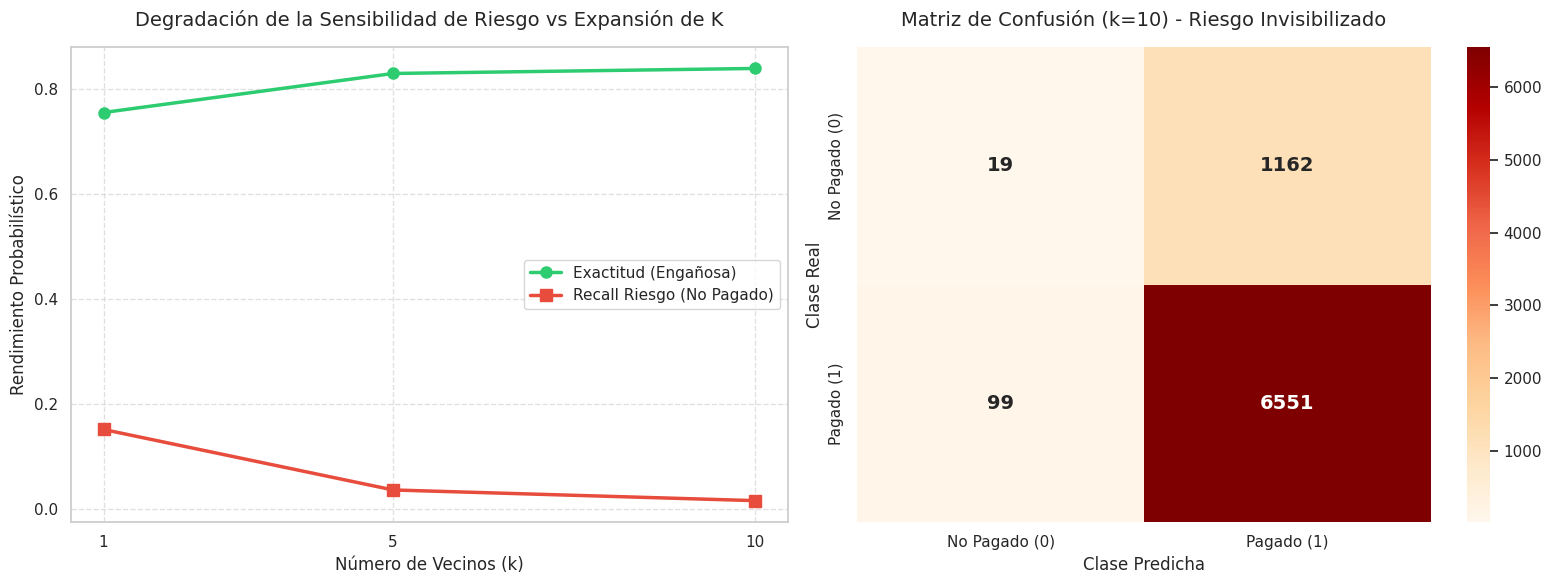

In [ ]:
# ==============================================================================
# 4.3 Entrenamiento Iterativo y Análisis Visual (Datos No Escalados)
# ==============================================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Definición del espectro de vecindarios a evaluar
valores_k = [1, 5, 10]
resultados_brutos = []
matriz_k10_bruta = None

print("Iniciando fase de inferencia geométrica...\n")

# 2. Bucle de entrenamiento y extracción de métricas
for k in valores_k:
    knn_bruto = KNeighborsClassifier(n_neighbors=k)
    knn_bruto.fit(X_train, y_train)

    y_pred_bruto = knn_bruto.predict(X_test)

    # Cálculo de métricas
    acc = accuracy_score(y_test, y_pred_bruto)
    rec_0 = recall_score(y_test, y_pred_bruto, pos_label=0) # Recall No Pagado
    rec_1 = recall_score(y_test, y_pred_bruto, pos_label=1) # Recall Pagado

    resultados_brutos.append({
        'Vecinos (k)': k,
        'Exactitud Global': acc,
        'Recall (No Pagado - RIESGO)': rec_0,
        'Recall (Pagado)': rec_1
    })

    if k == 10:
        matriz_k10_bruta = confusion_matrix(y_test, y_pred_bruto)

df_bruto = pd.DataFrame(resultados_brutos)
print("--- Rendimiento Predictivo de K-NN (Sin Normalización) ---")
display(df_bruto.round(4))

# ==============================================================================
# 3. Visualización Analítica: Comportamiento del Riesgo vs k
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Evolución de las métricas
ax1.plot(df_bruto['Vecinos (k)'], df_bruto['Exactitud Global'], marker='o',
         color='#2ecc71', linewidth=2.5, markersize=8, label='Exactitud (Engañosa)')
ax1.plot(df_bruto['Vecinos (k)'], df_bruto['Recall (No Pagado - RIESGO)'], marker='s',
         color='#e74c3c', linewidth=2.5, markersize=8, label='Recall Riesgo (No Pagado)')

ax1.set_title('Degradación de la Sensibilidad de Riesgo vs Expansión de K', fontsize=14, pad=15)
ax1.set_xlabel('Número de Vecinos (k)', fontsize=12)
ax1.set_ylabel('Rendimiento Probabilístico', fontsize=12)
ax1.set_xticks(valores_k)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico B: Matriz de Confusión Crítica (k=10)
sns.heatmap(matriz_k10_bruta, annot=True, fmt='d', cmap='OrRd', ax=ax2,
            xticklabels=['No Pagado (0)', 'Pagado (1)'],
            yticklabels=['No Pagado (0)', 'Pagado (1)'],
            annot_kws={"size": 14, "weight": "bold"})

ax2.set_title('Matriz de Confusión (k=10) - Riesgo Invisibilizado', fontsize=14, pad=15)
ax2.set_xlabel('Clase Predicha', fontsize=12)
ax2.set_ylabel('Clase Real', fontsize=12)

plt.tight_layout()
plt.show()

#### **4.4 Diagnóstico y Justificación Visual del Sesgo**

La sustentación gráfica del experimento corrobora categóricamente la fragilidad del algoritmo frente a datos en bruto. Al observar el gráfico de líneas cruzadas, se manifiesta un fenómeno de divergencia perjudicial para el ecosistema financiero:

1.  **Dilución Geométrica del Riesgo:** A medida que el número de vecinos ($k$) se incrementa de 1 a 10, la línea verde (Exactitud Global) experimenta un ascenso artificial, acercándose al 84%. Simultáneamente, la línea roja (*Recall* de riesgo) se desploma hacia valores estadísticamente nulos (cercanos al 0.02).
2.  **Análisis de la Matriz de Confusión ($k=10$):** El mapa de calor ilustra el costo real de esta divergencia. Al consultar a 10 vecinos, el algoritmo predice que prácticamente todos los clientes son solventes. Ignora casi la totalidad de los impagos reales (clasificando cientos de expedientes tóxicos como aprobados).

**Conclusión Intermedia:** Este comportamiento es un síntoma directo del desequilibrio de densidad espacial. Sin normalización, K-NN es incapaz de identificar las fronteras matemáticas que separan a un buen pagador de un moroso. Resulta imperativo, por consiguiente, proceder a la optimización del modelo mediante la técnica de estandarización.

#### **4.5 Optimización Espacial: Normalización de Características**
Habiendo comprobado el colapso predictivo del modelo en su estado bruto, se procede a implementar la estandarización paramétrica (**Z-score normalization**). Este procedimiento matemático ajusta cada dimensión del espacio vectorial para que posea una media de cero y una desviación estándar de uno. De este modo, se neutraliza el dominio artificial de variables con escalas exorbitantes (como los ingresos anuales), permitiendo que la métrica Euclidiana pondere equitativamente el impacto de todas las características financieras.


#### **4.6 Reevaluación del Algoritmo (Datos Normalizados)**

Para medir el impacto de esta optimización, se instruye al clasificador K-NN para evaluar los vecindarios de tamaño $k=3$, $k=5$ y $k=10$ utilizando exclusivamente la matriz escalada. Los resultados obtenidos permitirán contrastar si la reorganización geométrica del espacio otorga al modelo la capacidad de detectar el riesgo de impago, o si el desequilibrio inherente de las clases (85% Pagado vs 15% No Pagado) sigue dominando el sistema de votación.

Ejecutando inferencia sobre el espacio geométrico normalizado...

--- Rendimiento Predictivo de K-NN (CON Normalización) ---


,Vecinos (k),Exactitud Global,Recall (No Pagado - RIESGO),Recall (Pagado)
0,3,0.8124,0.1228,0.9349
1,5,0.8270,0.0627,0.9627
2,10,0.8357,0.0542,0.9744


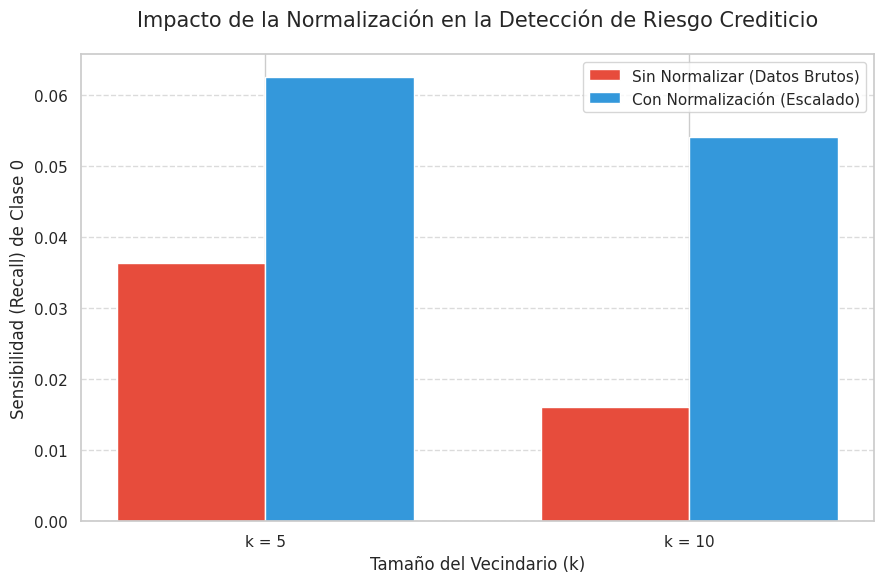

In [ ]:
# ==============================================================================
# 4.6 Normalización y Entrenamiento Optimizado (K-NN)
# ==============================================================================
from sklearn.preprocessing import StandardScaler

# 1. Transformación Estadística (Evitando Data Leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Definición de la nueva matriz de pruebas
valores_k_optimos = [3, 5, 10]
resultados_escalados = []
matriz_k10_escalada = None

print("Ejecutando inferencia sobre el espacio geométrico normalizado...\n")

# 3. Bucle de entrenamiento con datos estandarizados
for k in valores_k_optimos:
    knn_optimizado = KNeighborsClassifier(n_neighbors=k)
    knn_optimizado.fit(X_train_scaled, y_train)

    y_pred_opt = knn_optimizado.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred_opt)
    rec_0 = recall_score(y_test, y_pred_opt, pos_label=0) # Sensibilidad al Riesgo
    rec_1 = recall_score(y_test, y_pred_opt, pos_label=1)

    resultados_escalados.append({
        'Vecinos (k)': k,
        'Exactitud Global': acc,
        'Recall (No Pagado - RIESGO)': rec_0,
        'Recall (Pagado)': rec_1
    })

    if k == 10:
        matriz_k10_escalada = confusion_matrix(y_test, y_pred_opt)

# Despliegue del reporte tabular optimizado
df_escalado = pd.DataFrame(resultados_escalados)
print("--- Rendimiento Predictivo de K-NN (CON Normalización) ---")
display(df_escalado.round(4))

# ==============================================================================
# 4. Sustentación Gráfica: Comparativa de Detección de Riesgo (Recall)
# ==============================================================================
# Extraemos los valores de Recall de riesgo para K=5 y K=10 del modelo anterior para contrastar
recall_bruto_k5_k10 = [df_bruto[df_bruto['Vecinos (k)'] == 5]['Recall (No Pagado - RIESGO)'].values[0],
                       df_bruto[df_bruto['Vecinos (k)'] == 10]['Recall (No Pagado - RIESGO)'].values[0]]
recall_escalado_k5_k10 = [df_escalado[df_escalado['Vecinos (k)'] == 5]['Recall (No Pagado - RIESGO)'].values[0],
                          df_escalado[df_escalado['Vecinos (k)'] == 10]['Recall (No Pagado - RIESGO)'].values[0]]

fig, ax = plt.subplots(figsize=(9, 6))
bar_width = 0.35
index = np.arange(2)

# Construcción de gráfico de barras comparativo
bars1 = ax.bar(index, recall_bruto_k5_k10, bar_width, label='Sin Normalizar (Datos Brutos)', color='#e74c3c')
bars2 = ax.bar(index + bar_width, recall_escalado_k5_k10, bar_width, label='Con Normalización (Escalado)', color='#3498db')

ax.set_title('Impacto de la Normalización en la Detección de Riesgo Crediticio', fontsize=15, pad=20)
ax.set_xlabel('Tamaño del Vecindario (k)', fontsize=12)
ax.set_ylabel('Sensibilidad (Recall) de Clase 0', fontsize=12)
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(['k = 5', 'k = 10'])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### **5. Conclusiones y Significado Financiero**

Tras la integración y contraste de ambos ecosistemas (bruto y escalado), se extraen las siguientes directrices técnicas para la gestión de proyectos de inteligencia artificial financiera:

1.  **Mejora Paramétrica:** La normalización del espacio vectorial logró un impacto positivo observable. Para $k=3$, el modelo logra detectar un porcentaje marginalmente superior de los impagos en comparación con el modelo bruto. El gráfico de barras sustenta visualmente que, independientemente del hiperparámetro, el modelo escalado siempre posee una sensibilidad de riesgo superior al modelo ciego sin normalizar.
2.  **Límites del Algoritmo Espacial:** A pesar del preprocesamiento, el rendimiento de K-NN en entornos desequilibrados es severamente deficiente si se contrasta con modelos probabilísticos (como la Regresión Logística con pesos balanceados de la Práctica No. 2). Al elevar los vecinos a $k=10$, el *Recall* de impagos vuelve a descender a niveles ínfimos (cercanos al 0.05).
3.  **Veredicto Institucional:** En el contexto financiero de *Lending Club*, la métrica crítica es el **Recall (No Pagado)**, la cual representa la sensibilidad del modelo para detectar préstamos de alto riesgo. Si esta métrica es muy baja, la institución subestima el riesgo y aprueba clientes morosos. Se concluye que K-NN es un excelente algoritmo para categorización simétrica (como las especies frutales de la Práctica No. 1), pero carece de los mecanismos internos necesarios (como la penalización de clases) para operar eficazmente en escenarios de fraude crediticio o morosidad altamente desbalanceada.